In [9]:
import numpy as np
from scipy.linalg import expm, eigh

# ==================================================
# Pauli matrices
# ==================================================

I = np.eye(2, dtype=complex)

sx = np.array([[0,1],
               [1,0]], dtype=complex)

sy = np.array([[0,-1j],
               [1j,0]], dtype=complex)

sz = np.array([[1,0],
               [0,-1]], dtype=complex)

# ==================================================
# Tensor product operator acting on qubit i
# ==================================================
H2 = np.array([[2, 0, 0, 0],
               [0, 1, 1, 0],
               [0, 1, 1, 0],
               [0, 0, 0, 2]], dtype=complex)
def op_on_qubit(op, i, N):

    ops = []

    for q in range(N):
        if q == i:
            ops.append(op)
        else:
            ops.append(I)

    out = ops[0]

    for k in range(1, N):
        out = np.kron(out, ops[k])

    return out


def op_on_pair(op1, i, op2, j, N):

    ops = []

    for q in range(N):

        if q == i:
            ops.append(op1)

        elif q == j:
            ops.append(op2)

        else:
            ops.append(I)

    out = ops[0]

    for k in range(1, N):
        out = np.kron(out, ops[k])

    return out

# ==================================================
# System parameters
# ==================================================
def pair_operator(H2, i, j, N):
    """
    Embed a 4x4 two-qubit operator H2 acting on qubits i and j
    into the full 2^N Hilbert space.
    """

    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)

    for a in range(dim):
        bits_a = [(a >> (N-1-k)) & 1 for k in range(N)]

        for b in range(dim):
            bits_b = [(b >> (N-1-k)) & 1 for k in range(N)]

            # Spectator qubits must be identical
            ok = True
            for k in range(N):
                if k != i and k != j:
                    if bits_a[k] != bits_b[k]:
                        ok = False
                        break

            if not ok:
                continue

            ia = 2*bits_a[i] + bits_a[j]
            ib = 2*bits_b[i] + bits_b[j]

            H[a, b] = H2[ia, ib]

    return H
N = 4

theta = 0.6

dm2 = 1.0
E   = 1.0

omega = dm2/(4.0*E)
def interaction_matrix(N, dm2, E):
    """
    Build Jij = (dm2 / 4E) * (1 - cos(theta_ij)),
    with theta_ij = arccos(0.9) * |i-j|/(N-1).
    """
    i = np.arange(N)
    dij = np.abs(i[:, None] - i[None, :])   # |i-j|
    theta = np.arccos(0.9) * dij / (N - 1)
    J = (dm2 / (4.0 * E)) * (1.0 - np.cos(theta))
    return J
J = interaction_matrix(N, dm2, E)
# ==================================================
# Build Hamiltonian
# ==================================================

H = np.zeros((2**N, 2**N), dtype=complex)

for i in range(N):
    for j in range(i+1, N):
        H += J[i, j] * pair_operator(H2, i, j, N)
# ==================================================
# Initial state |0011>
# ==================================================
nu_e  = np.array([1,0], dtype=complex)
nu_mu = np.array([0,1], dtype=complex)

alpha = np.pi/2   # choose any value

nu_x = np.cos(alpha)*nu_e + np.sin(alpha)*nu_mu
psi0 = np.zeros(2**N, dtype=complex)

psi0 = np.kron(
            np.kron(
                np.kron(nu_e, nu_e),
                nu_x),
            nu_x)

psi0 = psi0.astype(complex)

# ==================================================
# Time evolution
# ==================================================
P_mu = np.array([[0,0],
                 [0,1]], dtype=complex)
Pmu1 = op_on_qubit(P_mu, 0, N)
times = np.linspace(0,200,10)

states = []
P1=[]
mu=omega*N
x=mu*times
for t in times:

    U = expm(-1j*H*t)

    psi = U @ psi0

    #states.append(psi)
    prob = np.real(np.vdot(psi, Pmu1 @ psi))
    P1.append(prob)

    

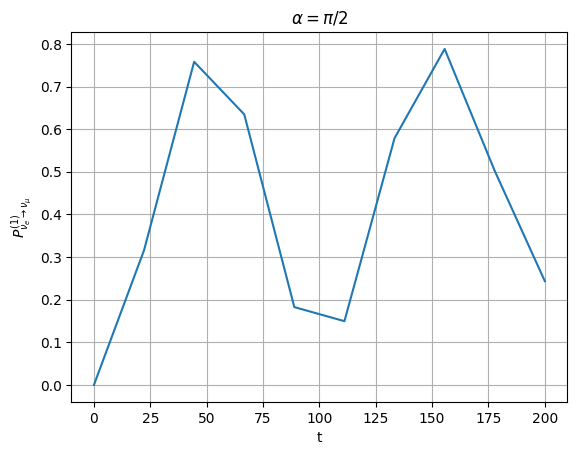

In [10]:
import matplotlib.pyplot as plt

plt.plot(x, P1)
plt.xlabel("t")
plt.ylabel(r"$P_{\nu_e\rightarrow\nu_\mu}^{(1)}$")
plt.title(r"$\alpha=\pi/2$")
plt.grid(True)
plt.show()

In [11]:
import numpy as np
from scipy.linalg import expm, eigh

# ==================================================
# Pauli matrices
# ==================================================

I = np.eye(2, dtype=complex)

sx = np.array([[0,1],
               [1,0]], dtype=complex)

sy = np.array([[0,-1j],
               [1j,0]], dtype=complex)

sz = np.array([[1,0],
               [0,-1]], dtype=complex)

# ==================================================
# Tensor product operator acting on qubit i
# ==================================================
H2 = np.array([[2, 0, 0, 0],
               [0, 1, 1, 0],
               [0, 1, 1, 0],
               [0, 0, 0, 2]], dtype=complex)
def op_on_qubit(op, i, N):

    ops = []

    for q in range(N):
        if q == i:
            ops.append(op)
        else:
            ops.append(I)

    out = ops[0]

    for k in range(1, N):
        out = np.kron(out, ops[k])

    return out


def op_on_pair(op1, i, op2, j, N):

    ops = []

    for q in range(N):

        if q == i:
            ops.append(op1)

        elif q == j:
            ops.append(op2)

        else:
            ops.append(I)

    out = ops[0]

    for k in range(1, N):
        out = np.kron(out, ops[k])

    return out

# ==================================================
# System parameters
# ==================================================
def pair_operator(H2, i, j, N):
    """
    Embed a 4x4 two-qubit operator H2 acting on qubits i and j
    into the full 2^N Hilbert space.
    """

    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)

    for a in range(dim):
        bits_a = [(a >> (N-1-k)) & 1 for k in range(N)]

        for b in range(dim):
            bits_b = [(b >> (N-1-k)) & 1 for k in range(N)]

            # Spectator qubits must be identical
            ok = True
            for k in range(N):
                if k != i and k != j:
                    if bits_a[k] != bits_b[k]:
                        ok = False
                        break

            if not ok:
                continue

            ia = 2*bits_a[i] + bits_a[j]
            ib = 2*bits_b[i] + bits_b[j]

            H[a, b] = H2[ia, ib]

    return H
N = 4

theta = 0.6

dm2 = 1.0
E   = 1.0

omega = dm2/(4.0*E)
def interaction_matrix(N, dm2, E):
    """
    Build Jij = (dm2 / 4E) * (1 - cos(theta_ij)),
    with theta_ij = arccos(0.9) * |i-j|/(N-1).
    """
    i = np.arange(N)
    dij = np.abs(i[:, None] - i[None, :])   # |i-j|
    theta = np.arccos(0.9) * dij / (N - 1)
    J = (dm2 / (4.0 * E)) * (1.0 - np.cos(theta))
    return J
J = interaction_matrix(N, dm2, E)
# ==================================================
# Build Hamiltonian
# ==================================================

H = np.zeros((2**N, 2**N), dtype=complex)

for i in range(N):
    for j in range(i+1, N):
        H += J[i, j] * pair_operator(H2, i, j, N)
# ==================================================
# Initial state |0011>
# ==================================================
nu_e  = np.array([1,0], dtype=complex)
nu_mu = np.array([0,1], dtype=complex)

alpha = np.pi/3   # choose any value

nu_x = np.cos(alpha)*nu_e + np.sin(alpha)*nu_mu
psi0 = np.zeros(2**N, dtype=complex)

psi0 = np.kron(
            np.kron(
                np.kron(nu_e, nu_e),
                nu_x),
            nu_x)

psi0 = psi0.astype(complex)

# ==================================================
# Time evolution
# ==================================================
P_mu = np.array([[0,0],
                 [0,1]], dtype=complex)
Pmu1 = op_on_qubit(P_mu, 0, N)
times = np.linspace(0,200,10)

states = []
P1=[]
mu=omega*N
x=mu*times
for t in times:

    U = expm(-1j*H*t)

    psi = U @ psi0

    #states.append(psi)
    prob = np.real(np.vdot(psi, Pmu1 @ psi))
    P1.append(prob)

    

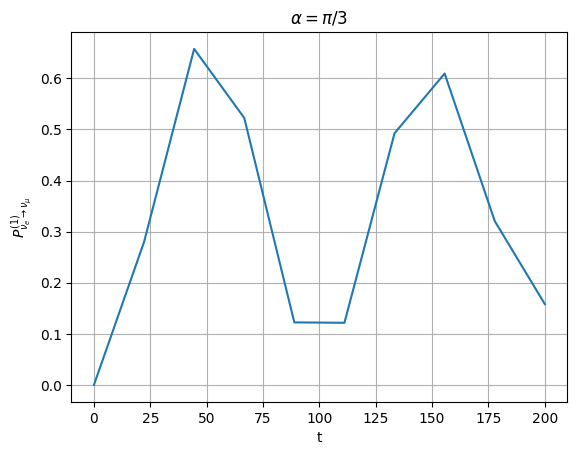

In [12]:
import matplotlib.pyplot as plt

plt.plot(x, P1)
plt.xlabel("t")
plt.ylabel(r"$P_{\nu_e\rightarrow\nu_\mu}^{(1)}$")
plt.title(r"$\alpha=\pi/3$")
plt.grid(True)
plt.show()

In [13]:
import numpy as np
from scipy.linalg import expm, eigh

# ==================================================
# Pauli matrices
# ==================================================

I = np.eye(2, dtype=complex)

sx = np.array([[0,1],
               [1,0]], dtype=complex)

sy = np.array([[0,-1j],
               [1j,0]], dtype=complex)

sz = np.array([[1,0],
               [0,-1]], dtype=complex)

# ==================================================
# Tensor product operator acting on qubit i
# ==================================================
H2 = np.array([[2, 0, 0, 0],
               [0, 1, 1, 0],
               [0, 1, 1, 0],
               [0, 0, 0, 2]], dtype=complex)
def op_on_qubit(op, i, N):

    ops = []

    for q in range(N):
        if q == i:
            ops.append(op)
        else:
            ops.append(I)

    out = ops[0]

    for k in range(1, N):
        out = np.kron(out, ops[k])

    return out


def op_on_pair(op1, i, op2, j, N):

    ops = []

    for q in range(N):

        if q == i:
            ops.append(op1)

        elif q == j:
            ops.append(op2)

        else:
            ops.append(I)

    out = ops[0]

    for k in range(1, N):
        out = np.kron(out, ops[k])

    return out

# ==================================================
# System parameters
# ==================================================
def pair_operator(H2, i, j, N):
    """
    Embed a 4x4 two-qubit operator H2 acting on qubits i and j
    into the full 2^N Hilbert space.
    """

    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)

    for a in range(dim):
        bits_a = [(a >> (N-1-k)) & 1 for k in range(N)]

        for b in range(dim):
            bits_b = [(b >> (N-1-k)) & 1 for k in range(N)]

            # Spectator qubits must be identical
            ok = True
            for k in range(N):
                if k != i and k != j:
                    if bits_a[k] != bits_b[k]:
                        ok = False
                        break

            if not ok:
                continue

            ia = 2*bits_a[i] + bits_a[j]
            ib = 2*bits_b[i] + bits_b[j]

            H[a, b] = H2[ia, ib]

    return H
N = 4

theta = 0.6

dm2 = 1.0
E   = 1.0

omega = dm2/(4.0*E)
def interaction_matrix(N, dm2, E):
    """
    Build Jij = (dm2 / 4E) * (1 - cos(theta_ij)),
    with theta_ij = arccos(0.9) * |i-j|/(N-1).
    """
    i = np.arange(N)
    dij = np.abs(i[:, None] - i[None, :])   # |i-j|
    theta = np.arccos(0.9) * dij / (N - 1)
    J = (dm2 / (4.0 * E)) * (1.0 - np.cos(theta))
    return J
J = interaction_matrix(N, dm2, E)
# ==================================================
# Build Hamiltonian
# ==================================================

H = np.zeros((2**N, 2**N), dtype=complex)

for i in range(N):
    for j in range(i+1, N):
        H += J[i, j] * pair_operator(H2, i, j, N)
# ==================================================
# Initial state |0011>
# ==================================================
nu_e  = np.array([1,0], dtype=complex)
nu_mu = np.array([0,1], dtype=complex)

alpha = np.pi/4   # choose any value

nu_x = np.cos(alpha)*nu_e + np.sin(alpha)*nu_mu
psi0 = np.zeros(2**N, dtype=complex)

psi0 = np.kron(
            np.kron(
                np.kron(nu_e, nu_e),
                nu_x),
            nu_x)

psi0 = psi0.astype(complex)

# ==================================================
# Time evolution
# ==================================================
P_mu = np.array([[0,0],
                 [0,1]], dtype=complex)
Pmu1 = op_on_qubit(P_mu, 0, N)
times = np.linspace(0,200,10)

states = []
P1=[]
mu=omega*N
x=mu*times
for t in times:

    U = expm(-1j*H*t)

    psi = U @ psi0

    #states.append(psi)
    prob = np.real(np.vdot(psi, Pmu1 @ psi))
    P1.append(prob)

    

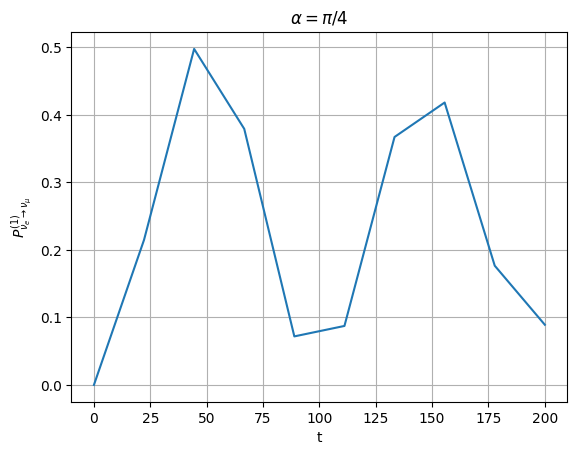

In [14]:
import matplotlib.pyplot as plt

plt.plot(x, P1)
plt.xlabel("t")
plt.ylabel(r"$P_{\nu_e\rightarrow\nu_\mu}^{(1)}$")
plt.title(r"$\alpha=\pi/4$")
plt.grid(True)
plt.show()

In [15]:
import numpy as np
from scipy.linalg import expm, eigh

# ==================================================
# Pauli matrices
# ==================================================

I = np.eye(2, dtype=complex)

sx = np.array([[0,1],
               [1,0]], dtype=complex)

sy = np.array([[0,-1j],
               [1j,0]], dtype=complex)

sz = np.array([[1,0],
               [0,-1]], dtype=complex)

# ==================================================
# Tensor product operator acting on qubit i
# ==================================================
H2 = np.array([[2, 0, 0, 0],
               [0, 1, 1, 0],
               [0, 1, 1, 0],
               [0, 0, 0, 2]], dtype=complex)
def op_on_qubit(op, i, N):

    ops = []

    for q in range(N):
        if q == i:
            ops.append(op)
        else:
            ops.append(I)

    out = ops[0]

    for k in range(1, N):
        out = np.kron(out, ops[k])

    return out


def op_on_pair(op1, i, op2, j, N):

    ops = []

    for q in range(N):

        if q == i:
            ops.append(op1)

        elif q == j:
            ops.append(op2)

        else:
            ops.append(I)

    out = ops[0]

    for k in range(1, N):
        out = np.kron(out, ops[k])

    return out

# ==================================================
# System parameters
# ==================================================
def pair_operator(H2, i, j, N):
    """
    Embed a 4x4 two-qubit operator H2 acting on qubits i and j
    into the full 2^N Hilbert space.
    """

    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)

    for a in range(dim):
        bits_a = [(a >> (N-1-k)) & 1 for k in range(N)]

        for b in range(dim):
            bits_b = [(b >> (N-1-k)) & 1 for k in range(N)]

            # Spectator qubits must be identical
            ok = True
            for k in range(N):
                if k != i and k != j:
                    if bits_a[k] != bits_b[k]:
                        ok = False
                        break

            if not ok:
                continue

            ia = 2*bits_a[i] + bits_a[j]
            ib = 2*bits_b[i] + bits_b[j]

            H[a, b] = H2[ia, ib]

    return H
N = 4

theta = 0.6

dm2 = 1.0
E   = 1.0

omega = dm2/(4.0*E)
def interaction_matrix(N, dm2, E):
    """
    Build Jij = (dm2 / 4E) * (1 - cos(theta_ij)),
    with theta_ij = arccos(0.9) * |i-j|/(N-1).
    """
    i = np.arange(N)
    dij = np.abs(i[:, None] - i[None, :])   # |i-j|
    theta = np.arccos(0.9) * dij / (N - 1)
    J = (dm2 / (4.0 * E)) * (1.0 - np.cos(theta))
    return J
J = interaction_matrix(N, dm2, E)
# ==================================================
# Build Hamiltonian
# ==================================================

H = np.zeros((2**N, 2**N), dtype=complex)

for i in range(N):
    for j in range(i+1, N):
        H += J[i, j] * pair_operator(H2, i, j, N)
# ==================================================
# Initial state |0011>
# ==================================================
nu_e  = np.array([1,0], dtype=complex)
nu_mu = np.array([0,1], dtype=complex)

alpha = np.pi/6   # choose any value

nu_x = np.cos(alpha)*nu_e + np.sin(alpha)*nu_mu
psi0 = np.zeros(2**N, dtype=complex)

psi0 = np.kron(
            np.kron(
                np.kron(nu_e, nu_e),
                nu_x),
            nu_x)

psi0 = psi0.astype(complex)

# ==================================================
# Time evolution
# ==================================================
P_mu = np.array([[0,0],
                 [0,1]], dtype=complex)
Pmu1 = op_on_qubit(P_mu, 0, N)
times = np.linspace(0,200,10)

states = []
P1=[]
mu=omega*N
x=mu*times
for t in times:

    U = expm(-1j*H*t)

    psi = U @ psi0

    #states.append(psi)
    prob = np.real(np.vdot(psi, Pmu1 @ psi))
    P1.append(prob)

    

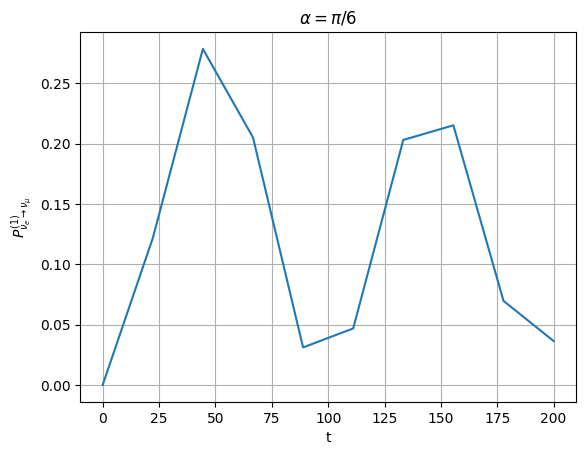

In [16]:
import matplotlib.pyplot as plt

plt.plot(x, P1)
plt.xlabel("t")
plt.ylabel(r"$P_{\nu_e\rightarrow\nu_\mu}^{(1)}$")
plt.title(r"$\alpha=\pi/6$")
plt.grid(True)
plt.show()